# **confusion_matrix**

In [1]:
import numpy as np

In [2]:
confusion_matrix = np.zeros((12, 12))

confusion_matrix[0]  = [8.83333333, 0., 0., 0.83333333, 0.16666667, 0., 0., 0., 0., 0.16666667, 0., 0.]
confusion_matrix[1]  = [0., 8.5, 1., 0.5, 0., 0., 0., 0., 0., 0., 0., 0.]
confusion_matrix[2]  = [0.16666667, 0.16666667, 9.16666667, 0.5, 0., 0., 0., 0., 0., 0., 0., 0.]
confusion_matrix[3]  = [0.5, 0., 0., 8.66666667, 0.16666667, 0., 0., 0., 0.16666667, 0.33333333, 0., 0.16666667]
confusion_matrix[4]  = [0.5, 0., 0., 0.16666667, 9., 0., 0., 0.16666667, 0., 0.33333333, 0., 0.]
confusion_matrix[5]  = [0.33333333, 0., 0., 0., 0., 9.66666667, 0.16666667, 0., 0., 0., 0., 0.]
confusion_matrix[6]  = [0., 0., 0.16666667, 0., 0., 0., 9.5, 0.16666667, 0., 0., 0.33333333, 0.]
confusion_matrix[7]  = [0., 0., 0.16666667, 0., 0., 0.5, 0., 9.33333333, 0., 0., 0., 0.]
confusion_matrix[8]  = [0., 0.16666667, 0.16666667, 0.16666667, 0., 0., 0., 0., 9.33333333, 0.16666667, 0.16666667, 0.]
confusion_matrix[9]  = [0.16666667, 0., 0.16666667, 0.33333333, 0.16666667, 0.16666667, 0., 0., 0.5, 8.5, 0., 0.]
confusion_matrix[10] = [0., 0., 0., 0., 0., 0., 1.16666667, 0., 0., 0., 9.16666667, 0.]
confusion_matrix[11] = [0., 0.16666667, 0., 0., 0., 0., 0., 0., 0., 0.16666667, 0., 9.33333333]

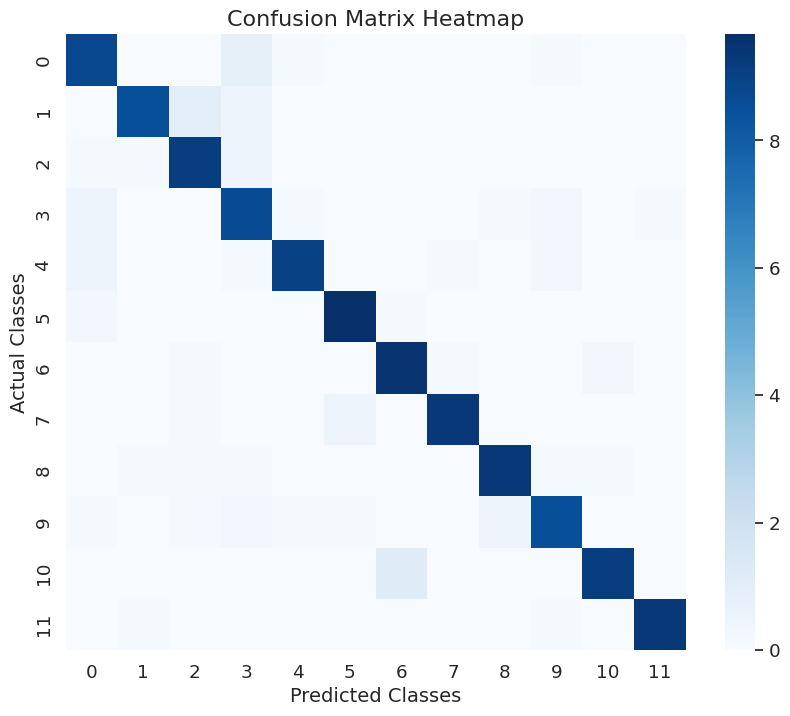

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 8))  # Adjust the size of the plot
sns.set(font_scale=1.2)  # Increase font size
sns.heatmap(confusion_matrix, annot=False, fmt=".2F", cmap="Blues", cbar=True, xticklabels=range(12), yticklabels=range(12))

# Add labels and title
plt.xlabel("Predicted Classes", fontsize=14)
plt.ylabel("Actual Classes", fontsize=14)
plt.title("Confusion Matrix Heatmap", fontsize=16)

# Show the plot
plt.show()

In [6]:
# Calculate the probabilities
confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1)[:, np.newaxis]

In [7]:
print(confusion_matrix)

[[0.88333333 0.         0.         0.08333333 0.01666667 0.
  0.         0.         0.         0.01666667 0.         0.        ]
 [0.         0.85       0.1        0.05       0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.01666667 0.01666667 0.91666667 0.05       0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.05       0.         0.         0.86666667 0.01666667 0.
  0.         0.         0.01666667 0.03333333 0.         0.01666667]
 [0.04918033 0.         0.         0.01639344 0.8852459  0.
  0.         0.01639344 0.         0.03278688 0.         0.        ]
 [0.03278688 0.         0.         0.         0.         0.95081967
  0.01639344 0.         0.         0.         0.         0.        ]
 [0.         0.         0.01639344 0.         0.         0.
  0.93442623 0.01639344 0.         0.         0.03278688 0.        ]
 [0.         0.         0.01666667 0.         0.         0.05
  0.         0.93333333 0. 

In [8]:
elements = list('ABCDEFGHIJKL')
label_indices = {label: idx for idx, label in enumerate(elements)}

# **4-gram**

In [9]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display
import random

# Step 1: Generate all possible combinations of elements (4**12 states)
elements = list('ABCDEFGHIJKL')

def generate_all_combinations(elements):
    return list(itertools.product(elements, repeat=4))

combinations = generate_all_combinations(elements)

# Step 2: Define function to calculate Hamming distance
def hamming_distance(s1, s2):
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))

# Step 2.5: Find indexes of wrong elements
def find_wrong_indexes(s1, s2):
    return [i for i, (el1, el2) in enumerate(zip(s1, s2)) if el1 != el2]



# Step 3: Calculate minimum Hamming distance and prediction
def find_min_distance_and_prediction(combinations, true_labels):
    results = []
    for comb in combinations:
        min_distance = float('inf')
        closest_labels = []
        for label in true_labels:
            distance = hamming_distance(comb, label)
            if distance < min_distance:
                min_distance = distance
                closest_labels = [label]
            elif distance == min_distance:
                closest_labels.append(label)


        # Calculate probabilities for closest labels based on wrong indexes
        ps = []
        for label in closest_labels:
            wrong_indexes = find_wrong_indexes(comb, label)
            prob = np.prod([confusion_matrix[label_indices[label[i]], label_indices[comb[i]]] for i in wrong_indexes])
            ps.append(prob)

        # Select the label with the maximum probability
        max_prob_index = np.argmax(ps)
        closest_label = closest_labels[max_prob_index]

        # Select the label with the maximum probability
        if sum(ps) > 0:  # Check to prevent division by zero
            mprob = (ps / sum(ps))[max_prob_index]
        else:
            mprob = 0  # Set probability to 0 if sum(ps) is zero


        # Add a row with the combination, minimum distance, closest label, and all closest labels
        results.append((tuple(comb), min_distance, closest_label, closest_labels, mprob))
    return results

# Define your true labels
true_labels = [('A', 'B', 'C', 'L'), ('C', 'A', 'C', 'L'), ('D', 'F', 'B', 'D'), ('A', 'B', 'C', 'D')]  # Replace with your actual true labels

# Calculate results
results = find_min_distance_and_prediction(combinations, true_labels)

# Step 4: Create and display the table
table = pd.DataFrame(results, columns=['Combination', 'Min Hamming Distance', 'Predicted True Label', 'All Closest Labels', 'mprob'])


# Replace NaN values in 'mprob' column with 0
#table['mprob'] = table['mprob'].fillna(0)


display(table)


,Combination,Min Hamming Distance,Predicted True Label,All Closest Labels,mprob
0,"(A, A, A, A)",3,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (A, B, C, D)]",0.0
1,"(A, A, A, B)",3,"(C, A, C, L)","[(A, B, C, L), (C, A, C, L), (A, B, C, D)]",1.0
2,"(A, A, A, C)",3,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (A, B, C, D)]",0.0
3,"(A, A, A, D)",2,"(A, B, C, D)","[(A, B, C, D)]",0.0
4,"(A, A, A, E)",3,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (A, B, C, D)]",0.0
...,...,...,...,...,...
20731,"(L, L, L, H)",4,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (D, F, B, D), (A,...",0.0
20732,"(L, L, L, I)",4,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (D, F, B, D), (A,...",0.0
20733,"(L, L, L, J)",4,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (D, F, B, D), (A,...",0.0
20734,"(L, L, L, K)",4,"(A, B, C, L)","[(A, B, C, L), (C, A, C, L), (D, F, B, D), (A,...",0.0


In [12]:
# Step 5: Calculate probability for each true label
def calculate_probabilities(results, true_labels, confusion_matrix):
    label_indices = {label: idx for idx, label in enumerate(elements)}
    probabilities = {label: 0.0 for label in true_labels}

    for i, label in enumerate(true_labels):
        for comb, min_distance, closest_label, closest_labels, mprob in results:
            p1 = np.prod([confusion_matrix[label_indices[label[j]], label_indices[comb[j]]] for j in range(4)])
            p2 = 1 if closest_label==label else 0
           # p3 = mprob #/ len(closest_labels)
            probabilities[label] += p1 * p2 # * p3


    return probabilities

# Step 6: Compute probabilities
probabilities = calculate_probabilities(results, true_labels, confusion_matrix)

# Step 7: Display the probabilities in a table
probability_table = pd.DataFrame(list(probabilities.items()), columns=['True Label', 'Computed Probability'])
display(probability_table)

,True Label,Computed Probability
0,"(A, B, C, L)",0.982518
1,"(C, A, C, L)",0.993788
2,"(D, F, B, D)",0.993374
3,"(A, B, C, D)",0.981066


In [13]:
probability_array4 = probability_table['Computed Probability'].to_numpy()

In [14]:
mean_value = np.mean(probability_array4)
print("Mean of elements in the array:", mean_value)

Mean of elements in the array: 0.987686564670816


# **3-gram:**

In [15]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display
import random

# Step 1: Generate all possible combinations of elements (2**12 states)
elements = list('ABCDEFGHIJKL')

def generate_all_combinations(elements):
    return list(itertools.product(elements, repeat=3))

combinations = generate_all_combinations(elements)

# Step 2: Define function to calculate Hamming distance
def hamming_distance(s1, s2):
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))

# Step 2.5: Find indexes of wrong elements
def find_wrong_indexes(s1, s2):
    return [i for i, (el1, el2) in enumerate(zip(s1, s2)) if el1 != el2]


# Step 3: Calculate minimum Hamming distance and prediction
def find_min_distance_and_prediction(combinations, true_labels):
    results = []
    for comb in combinations:
        min_distance = float('inf')
        closest_labels = []
        for label in true_labels:
            distance = hamming_distance(comb, label)
            if distance < min_distance:
                min_distance = distance
                closest_labels = [label]
            elif distance == min_distance:
                closest_labels.append(label)


        # Calculate probabilities for closest labels based on wrong indexes
        ps = []
        for label in closest_labels:
            wrong_indexes = find_wrong_indexes(comb, label)
            prob = np.prod([confusion_matrix[label_indices[label[i]], label_indices[comb[i]]] for i in wrong_indexes])
            ps.append(prob)

        # Select the label with the maximum probability
        max_prob_index = np.argmax(ps)
        closest_label = closest_labels[max_prob_index]


        # Select the label with the maximum probability
        if sum(ps) > 0:  # Check to prevent division by zero
            mprob = (ps / sum(ps))[max_prob_index]
        else:
            mprob = 0  # Set probability to 0 if sum(ps) is zero



        # Add a row with the combination, minimum distance, closest label, and all closest labels
        results.append((tuple(comb), min_distance, closest_label, closest_labels, mprob))
    return results

# Define your true labels
true_labels = [('B', 'B', 'F'), ('A', 'B', 'A'), ('A', 'B', 'C'), ('E', 'E', 'D'), ('C', 'A', 'C'), ('D', 'D', 'E'), ('C', 'F', 'D'), ('D', 'D', 'C'), ('A', 'A', 'C'), ('F', 'D', 'D'), ('F', 'F', 'D'), ('D', 'D', 'D'), ('C', 'D', 'L'), ('A', 'A', 'I'), ('F', 'D', 'L'), ('F', 'A', 'L'), ('G', 'A', 'A'), ('B', 'G', 'A')]  # Replace with your actual true labels

# Calculate results
results = find_min_distance_and_prediction(combinations, true_labels)

# Step 4: Create and display the table
table = pd.DataFrame(results, columns=['Combination', 'Min Hamming Distance', 'Predicted True Label', 'All Closest Labels', 'mprob'])

# Replace NaN values in 'mprob' column with 0
table['mprob'] = table['mprob'].fillna(0)

display(table)


,Combination,Min Hamming Distance,Predicted True Label,All Closest Labels,mprob
0,"(A, A, A)",1,"(A, A, C)","[(A, B, A), (A, A, C), (A, A, I), (G, A, A)]",1.000000
1,"(A, A, B)",1,"(A, A, C)","[(A, A, C), (A, A, I)]",0.504132
2,"(A, A, C)",0,"(A, A, C)","[(A, A, C)]",1.000000
3,"(A, A, D)",1,"(A, A, C)","[(A, A, C), (A, A, I)]",0.753086
4,"(A, A, E)",1,"(A, A, C)","[(A, A, C), (A, A, I)]",0.000000
...,...,...,...,...,...
1723,"(L, L, H)",3,"(D, D, E)","[(B, B, F), (A, B, A), (A, B, C), (E, E, D), (...",1.000000
1724,"(L, L, I)",2,"(A, A, I)","[(A, A, I)]",0.000000
1725,"(L, L, J)",3,"(D, D, D)","[(B, B, F), (A, B, A), (A, B, C), (E, E, D), (...",0.504132
1726,"(L, L, K)",3,"(B, B, F)","[(B, B, F), (A, B, A), (A, B, C), (E, E, D), (...",0.000000


In [16]:
# Step 5: Calculate probability for each true label
def calculate_probabilities(results, true_labels, confusion_matrix):
    label_indices = {label: idx for idx, label in enumerate(elements)}
    probabilities = {label: 0.0 for label in true_labels}

    for i, label in enumerate(true_labels):
        for comb, min_distance, closest_label, closest_labels, mprob in results:
            p1 = np.prod([confusion_matrix[label_indices[label[j]], label_indices[comb[j]]] for j in range(3)])
            p2 = 1 if closest_label==label else 0
           # p3 = mprob #/ len(closest_labels)
            probabilities[label] += p1 * p2 # * p3

    return probabilities

# Step 6: Compute probabilities
probabilities = calculate_probabilities(results, true_labels, confusion_matrix)

# Step 7: Display the probabilities in a table
probability_table = pd.DataFrame(list(probabilities.items()), columns=['True Label', 'Computed Probability'])
display(probability_table)

,True Label,Computed Probability
0,"(B, B, F)",0.983402
1,"(A, B, A)",0.980153
2,"(A, B, C)",0.878861
3,"(E, E, D)",0.950766
4,"(C, A, C)",0.923250
5,"(D, D, E)",0.898962
6,"(C, F, D)",0.946662
7,"(D, D, C)",0.842037
8,"(A, A, C)",0.972648
9,"(F, D, D)",0.942450


In [17]:
probability_array3 = probability_table['Computed Probability'].to_numpy()

In [18]:
mean_value = np.mean(probability_array3)
print("Mean of elements in the array:", mean_value)

Mean of elements in the array: 0.9402470395827245


# **2-gram:**

In [19]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display

# Step 1: Generate all possible combinations of elements (2**12 states)
elements = list('ABCDEFGHIJKL')

def generate_all_combinations(elements):
    return list(itertools.product(elements, repeat=2))

combinations = generate_all_combinations(elements)

# Step 2: Define function to calculate Hamming distance
def hamming_distance(s1, s2):
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))


# Step 2.5: Find indexes of wrong elements
def find_wrong_indexes(s1, s2):
    return [i for i, (el1, el2) in enumerate(zip(s1, s2)) if el1 != el2]



# Step 3: Calculate minimum Hamming distance and prediction
def find_min_distance_and_prediction(combinations, true_labels):
    results = []
    for comb in combinations:
        min_distance = float('inf')
        closest_labels = []
        for label in true_labels:
            distance = hamming_distance(comb, label)
            if distance < min_distance:
                min_distance = distance
                closest_labels = [label]
            elif distance == min_distance:
                closest_labels.append(label)

        # Calculate probabilities for closest labels based on wrong indexes
        ps = []
        for label in closest_labels:
            wrong_indexes = find_wrong_indexes(comb, label)
            prob = np.prod([confusion_matrix[label_indices[label[i]], label_indices[comb[i]]] for i in wrong_indexes])
            ps.append(prob)

        # Select the label with the maximum probability
        max_prob_index = np.argmax(ps)
        closest_label = closest_labels[max_prob_index]

        # Select the label with the maximum probability
        if sum(ps) > 0:  # Check to prevent division by zero
            mprob = (ps / sum(ps))[max_prob_index]
        else:
            mprob = 0  # Set probability to 0 if sum(ps) is zero



        # Add a row with the combination, minimum distance, closest label, and all closest labels
        results.append((tuple(comb), min_distance, closest_label, closest_labels, mprob))
    return results

# Define your true labels
true_labels = [('F', 'C'), ('C', 'B'), ('G', 'C'), ('C', 'F'), ('F', 'A'), ('F', 'D'), ('F', 'I'), ('D', 'C'), ('B', 'D'), ('A', 'C'), ('A', 'A'), ('C', 'D'), ('I', 'E'), ('H', 'D'), ('A', 'F'), ('B', 'C'), ('C', 'I'), ('B', 'F'), ('D', 'E')]  # Replace with your actual true labels

# Calculate results
results = find_min_distance_and_prediction(combinations, true_labels)

# Step 4: Create and display the table
table = pd.DataFrame(results, columns=['Combination', 'Min Hamming Distance', 'Predicted True Label', 'All Closest Labels', 'mprob'])
display(table)


,Combination,Min Hamming Distance,Predicted True Label,All Closest Labels,mprob
0,"(A, A)",0,"(A, A)","[(A, A)]",1.000000
1,"(A, B)",1,"(C, B)","[(C, B), (A, C), (A, A), (A, F)]",0.500000
2,"(A, C)",0,"(A, C)","[(A, C)]",1.000000
3,"(A, D)",1,"(A, A)","[(F, D), (B, D), (A, C), (A, A), (C, D), (H, D...",0.455904
4,"(A, E)",1,"(D, E)","[(A, C), (A, A), (I, E), (A, F), (D, E)]",0.750000
...,...,...,...,...,...
139,"(L, H)",2,"(D, E)","[(F, C), (C, B), (G, C), (C, F), (F, A), (F, D...",1.000000
140,"(L, I)",1,"(F, I)","[(F, I), (C, I)]",0.000000
141,"(L, J)",2,"(D, E)","[(F, C), (C, B), (G, C), (C, F), (F, A), (F, D...",1.000000
142,"(L, K)",2,"(F, C)","[(F, C), (C, B), (G, C), (C, F), (F, A), (F, D...",0.000000


In [20]:
# Step 5: Calculate probability for each true label
def calculate_probabilities(results, true_labels, confusion_matrix):
    label_indices = {label: idx for idx, label in enumerate(elements)}
    probabilities = {label: 0.0 for label in true_labels}

    for i, label in enumerate(true_labels):
        for comb, min_distance, closest_label, closest_labels, mprob in results:
            p1 = np.prod([confusion_matrix[label_indices[label[j]], label_indices[comb[j]]] for j in range(2)])
            p2 = 1 if closest_label==label else 0
           # p3 = mprob #/ len(closest_labels)
            probabilities[label] += p1 * p2 # * p3

    return probabilities

# Step 6: Compute probabilities
probabilities = calculate_probabilities(results, true_labels, confusion_matrix)

# Step 7: Display the probabilities in a table
probability_table = pd.DataFrame(list(probabilities.items()), columns=['True Label', 'Computed Probability'])
display(probability_table)

,True Label,Computed Probability
0,"(F, C)",0.887432
1,"(C, B)",0.941667
2,"(G, C)",0.979508
3,"(C, F)",0.886612
4,"(F, A)",0.855738
5,"(F, D)",0.871585
6,"(F, I)",0.933620
7,"(D, C)",0.855556
8,"(B, D)",0.893333
9,"(A, C)",0.825000


In [21]:
probability_array2 = probability_table['Computed Probability'].to_numpy()

In [22]:
mean_value = np.mean(probability_array2)
print("Mean of elements in the array:", mean_value)

Mean of elements in the array: 0.8976730139124364


# **1-gram**

In [23]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display
import random

# Step 1: Generate all possible combinations of elements (1**12 states)
elements = list('ABCDEFGHIJKL')

def generate_all_combinations(elements):
    return list(itertools.product(elements, repeat=1))

combinations = generate_all_combinations(elements)

# Step 2: Define function to calculate Hamming distance
def hamming_distance(s1, s2):
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))


# Step 2.5: Find indexes of wrong elements
def find_wrong_indexes(s1, s2):
    return [i for i, (el1, el2) in enumerate(zip(s1, s2)) if el1 != el2]


# Step 3: Calculate minimum Hamming distance and prediction
def find_min_distance_and_prediction(combinations, true_labels):
    results = []
    for comb in combinations:
        min_distance = float('inf')
        closest_labels = []
        for label in true_labels:
            distance = hamming_distance(comb, label)
            if distance < min_distance:
                min_distance = distance
                closest_labels = [label]
            elif distance == min_distance:
                closest_labels.append(label)


        # Calculate probabilities for closest labels based on wrong indexes
        ps = []
        for label in closest_labels:
            wrong_indexes = find_wrong_indexes(comb, label)
            prob = np.prod([confusion_matrix[label_indices[label[i]], label_indices[comb[i]]] for i in wrong_indexes])
            ps.append(prob)

        # Select the label with the maximum probability
        max_prob_index = np.argmax(ps)
        closest_label = closest_labels[max_prob_index]

        # Select the label with the maximum probability
        if sum(ps) > 0:  # Check to prevent division by zero
            mprob = (ps / sum(ps))[max_prob_index]
        else:
            mprob = 0  # Set probability to 0 if sum(ps) is zero



        # Add a row with the combination, minimum distance, closest label, and all closest labels
        results.append((tuple(comb), min_distance, closest_label, closest_labels, mprob))
    return results

# Define your true labels
true_labels = [('C',), ('F',), ('J',), ('I',), ('A',), ('K',), ('L',)]  # Replace with your actual true labels

# Calculate results
results = find_min_distance_and_prediction(combinations, true_labels)

# Step 4: Create and display the table
table = pd.DataFrame(results, columns=['Combination', 'Min Hamming Distance', 'Predicted True Label', 'All Closest Labels', 'mprob'])
display(table)


,Combination,Min Hamming Distance,Predicted True Label,All Closest Labels,mprob
0,"(A,)",0,"(A,)","[(A,)]",1.000000
1,"(B,)",1,"(L,)","[(C,), (F,), (J,), (I,), (A,), (K,), (L,)]",0.342761
2,"(C,)",0,"(C,)","[(C,)]",1.000000
3,"(D,)",1,"(A,)","[(C,), (F,), (J,), (I,), (A,), (K,), (L,)]",0.455224
4,"(E,)",1,"(A,)","[(C,), (F,), (J,), (I,), (A,), (K,), (L,)]",0.500000
5,"(F,)",0,"(F,)","[(F,)]",1.000000
6,"(G,)",1,"(K,)","[(C,), (F,), (J,), (I,), (A,), (K,), (L,)]",0.873211
7,"(H,)",1,"(C,)","[(C,), (F,), (J,), (I,), (A,), (K,), (L,)]",0.000000
8,"(I,)",0,"(I,)","[(I,)]",1.000000
9,"(J,)",0,"(J,)","[(J,)]",1.000000


In [24]:
# Step 5: Calculate probability for each true label
def calculate_probabilities(results, true_labels, confusion_matrix):
    label_indices = {label: idx for idx, label in enumerate(elements)}
    probabilities = {label: 0.0 for label in true_labels}

    for i, label in enumerate(true_labels):
        for comb, min_distance, closest_label, closest_labels, mprob in results:
            p1 = np.prod([confusion_matrix[label_indices[label[j]], label_indices[comb[j]]] for j in range(1)])
            p2 = 1 if closest_label==label else 0
           # p3 = mprob #/ len(closest_labels)
            probabilities[label] += p1 * p2 # * p3


    return probabilities

# Step 6: Compute probabilities
probabilities = calculate_probabilities(results, true_labels, confusion_matrix)

# Step 7: Display the probabilities in a table
probability_table = pd.DataFrame(list(probabilities.items()), columns=['True Label', 'Computed Probability'])
display(probability_table)

,True Label,Computed Probability
0,"(C,)",0.916667
1,"(F,)",0.950820
2,"(J,)",0.850000
3,"(I,)",0.918033
4,"(A,)",0.983333
5,"(K,)",1.000000
6,"(L,)",0.982759


In [25]:
probability_array1 = probability_table['Computed Probability'].to_numpy()

In [26]:
mean_value = np.mean(probability_array1)
print("Mean of elements in the array:", mean_value)

Mean of elements in the array: 0.9430872965835398


# **Mean :**

In [27]:
mean_value = np.mean(np.concatenate([probability_array1, probability_array2, probability_array3, probability_array4]))
print("Mean of elements in the array:", mean_value)

Mean of elements in the array: 0.9277623189915287
